# Sector / ramp-leg diagnostics

Goal: find out **why a transition peak is dark** in the LSZ signal, by separating the three possible causes:

1. **Population**: state m has no weight at the end of ramp 1 (`|u_m^↑|² ≈ 0`).
2. **Coherence / symmetry block**: populations are nonzero, but the off-diagonal density-matrix element `ρ_{mn}` at the end of ramp 1 is exactly zero (sector decoupling — e.g. SWAP symmetry separates the singlet from the symmetric sector).
3. **Ramp-down closure**: `|u_m^↑|` is fine, `|ρ_{mn}|` is fine, but the ramp-down sends `|E_m(tr)⟩` to a state orthogonal to `ψ_initial`, so `|u_m^↓| ≈ 0` and the peak is killed at projection.

The notebook prints `u_m^↑`, `u_m^↓`, the product `u_m^↑ · u_m^↓` (the peak-weight building block), and the full coherence matrix `|ρ_{mn}|` at the end of ramp 1.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qutip as qt

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment

## Parameters

Mirror the setup from `LSZ_main.ipynb` you've been debugging. Adjust freely.

In [39]:
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

epsilon       = 1
ramp_time     = 3.0
dt            = 0.1

# Two-qubit symmetric Hamiltonian (the case where SWAP is conserved).
local_z_list  = np.array([1, 1])
local_x_list  = np.array([1, 1])
zz_terms      = np.array([4])
n_qubits      = len(local_z_list)
assym_coeffs  = [1, 2]  # asymmetric ramp speeds — try [1,1] too

# Initial state with overlap on *both* SWAP sectors so a dark peak can't be
# blamed on the initial state alone.
# psi_p = (qt.tensor([ket1, ket0]) + qt.tensor([ket0, ket1])) / np.sqrt(2)
# psi_m = (qt.tensor([ket1, ket0]) - qt.tensor([ket0, ket1])) / np.sqrt(2)
# psi0  = 0.5*(qt.tensor([ket0, ket0]) + psi_p + psi_m + qt.tensor([ket1, ket1]))

psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1)]*n_qubits)


psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1),1/np.sqrt(2)*(ket0 + ket1)])

H_target_dict = {'local_z': local_z_list, 'local_x': local_x_list, 'two_body': zz_terms}

# Build a single experiment instance for the diagnostic.
evo = LSZ_experiment(n_qubits, epsilon, H_target_dict, ramp_time,
                     wait_time=0, dt=dt,
                     assymetry_factors=assym_coeffs,
                     initial_state=psi0)

print('tr =', evo.tr, '   tf =', evo.tf)
print('asymmetry =', evo.assymetry_list)

tr = 3.0    tf = 6.0
asymmetry = [1, 2]


## Forward leg: `u_m^↑ = ⟨E_m(tr) | U_↑ | ψ_initial⟩`

End of ramp 1, projected on H(tr) eigenstates. Already what `validate_state_vector` returns, computed inline here for clarity.

In [40]:
sim_r1, _, _ = evo.time_evolution()
psi_tr = sim_r1.states[-1].full().flatten()

H_tr = evo.H_numpy(evo.tr)
egvals_tr, egvecs_tr = np.linalg.eigh(H_tr)

u_up = egvecs_tr.conj().T @ psi_tr
p_up = np.abs(u_up)**2

print('Eigenvalues of H(tr):', np.round(egvals_tr, 4))
print()
print(f'{"m":>3} {"|u_m^up|":>12} {"|u_m^up|^2":>14}')
for m in range(len(u_up)):
    print(f'{m:>3} {abs(u_up[m]):>12.4e} {p_up[m]:>14.4e}')

Eigenvalues of H(tr): [-4.4983 -4.      2.2927  6.2056]

  m     |u_m^up|     |u_m^up|^2
  0   4.2335e-01     1.7922e-01
  1   5.2061e-01     2.7104e-01
  2   6.7278e-01     4.5263e-01
  3   3.1163e-01     9.7114e-02


## Coherence matrix `|ρ_{mn}|` at the end of ramp 1

In the H(tr) eigenbasis. If a peak `m↔n` is dark and the populations on m and n are both nonzero, but `|ρ_{mn}| ≈ 0`, the channel is closed by **sector decoupling** — no ramp-down change can fix it without breaking the symmetry that produces the block.

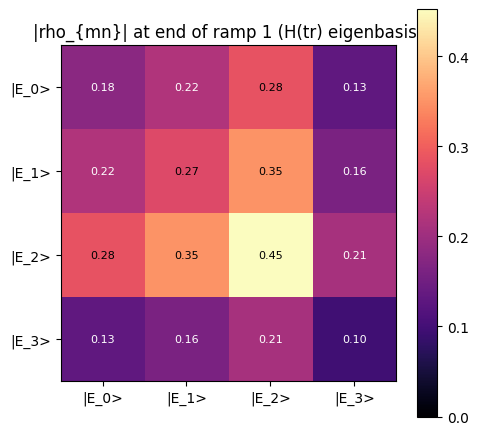

Pairs with sqrt(p_m p_n) > 1e-3 but |rho_{mn}| < 1e-6:


In [41]:
# Pure-state density matrix in the H(tr) eigenbasis.
rho_eig = np.outer(u_up, u_up.conj())
coh_mag = np.abs(rho_eig)

N = coh_mag.shape[0]
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(coh_mag, cmap='magma', vmin=0, vmax=coh_mag.max())
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{coh_mag[i,j]:.2f}',
                ha='center', va='center',
                color='w' if coh_mag[i,j] < coh_mag.max()*0.5 else 'k', fontsize=8)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([f'|E_{m}>' for m in range(N)])
ax.set_yticklabels([f'|E_{m}>' for m in range(N)])
ax.set_title('|rho_{mn}| at end of ramp 1 (H(tr) eigenbasis)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Pairs with sqrt(p_m p_n) > 1e-3 but |rho_{mn}| < 1e-6:')
for m in range(N):
    for n in range(m+1, N):
        ideal = np.sqrt(p_up[m]*p_up[n])
        if ideal > 1e-3 and coh_mag[m,n] < 1e-6:
            print(f'  (m,n)=({m},{n})  p_m={p_up[m]:.3e}  p_n={p_up[n]:.3e}  '
                  f'sqrt(p_m p_n)={ideal:.3e}  |rho|={coh_mag[m,n]:.3e}')

## Backward leg: `u_m^↓ = ⟨ψ_initial | U_↓ | E_m(tr)⟩`

For each eigenstate `|E_m(tr)⟩` of the wait Hamiltonian, prepare it at `t = tr` and evolve through the ramp-down to `t = tf`, then project on `ψ_initial`. Because `time_evolution` always starts at `t = 0`, we build a dedicated ramp-down by re-using the qutip time-dependent Hamiltonian on the interval `[tr, tf]` with `qt.sesolve`.

In [42]:
H_qt = evo.H_qutip()
t_list_r2 = np.linspace(evo.tr, evo.tf, max(100, int(evo.tr / evo.dt)))

u_down = np.zeros(N, dtype=complex)
for m in range(N):
    # Eigenstate of H(tr) as a qutip ket, in the standard computational basis.
    vec = egvecs_tr[:, m]
    state_data = vec.reshape(-1, 1)
    psi_m_qt = qt.Qobj(state_data, dims=[[2]*n_qubits, [1]*n_qubits])
    sim_back = qt.sesolve(H_qt, psi_m_qt, t_list_r2)
    psi_tf = sim_back.states[-1].full().flatten()
    psi_init = psi0.full().flatten()
    u_down[m] = np.vdot(psi_init, psi_tf)

p_down = np.abs(u_down)**2

print(f'{"m":>3} {"|u_m^up|":>12} {"|u_m^down|":>12} '
      f'{"|u_up*u_down|":>16} {"|u_up|*|u_down|":>16}')
for m in range(N):
    prod = u_up[m] * u_down[m]
    print(f'{m:>3} {abs(u_up[m]):>12.4e} {abs(u_down[m]):>12.4e} '
          f'{abs(prod):>16.4e} {abs(u_up[m])*abs(u_down[m]):>16.4e}')

  m     |u_m^up|   |u_m^down|    |u_up*u_down|  |u_up|*|u_down|
  0   4.2335e-01   4.2335e-01       1.7922e-01       1.7922e-01
  1   5.2061e-01   5.2062e-01       2.7104e-01       2.7104e-01
  2   6.7278e-01   6.7278e-01       4.5263e-01       4.5263e-01
  3   3.1163e-01   3.1162e-01       9.7111e-02       9.7111e-02


## Peak amplitudes

Each oscillation at frequency `|E_m − E_n|` enters the signal with weight

```
A_{mn} ∝ |u_m^↑ · u_m^↓| · |u_n^↑ · u_n^↓|
```

Compare against the "forward-only" weight `|u_m^↑|² · |u_n^↑|²` that holds when the ramps are mirror-symmetric. A row where `A_{mn}` is much smaller than the forward-only estimate is a peak being closed by the ramp-down.

In [43]:
amp_full = np.abs(u_up * u_down)
amp_fwd  = np.abs(u_up)**2

rows = []
for m in range(N):
    for n in range(m+1, N):
        f_mn = abs(egvals_tr[m] - egvals_tr[n])
        a_full = amp_full[m] * amp_full[n]
        a_fwd  = amp_fwd[m]  * amp_fwd[n]
        rows.append((m, n, f_mn, a_full, a_fwd))

print(f'{"(m,n)":>8} {"|E_m-E_n|":>12} {"A_mn (full)":>14} {"A_mn (fwd-only)":>18} {"ratio":>10}')
for m, n, f, a_full, a_fwd in rows:
    ratio = a_full / a_fwd if a_fwd > 1e-15 else float('nan')
    print(f'({m},{n}){"":>3} {f:>12.4f} {a_full:>14.4e} {a_fwd:>18.4e} {ratio:>10.3f}')

   (m,n)    |E_m-E_n|    A_mn (full)    A_mn (fwd-only)      ratio
(0,1)          0.4983     4.8576e-02         4.8576e-02      1.000
(0,2)          6.7910     8.1121e-02         8.1121e-02      1.000
(0,3)         10.7038     1.7405e-02         1.7405e-02      1.000
(1,2)          6.2927     1.2268e-01         1.2268e-01      1.000
(1,3)         10.2056     2.6321e-02         2.6322e-02      1.000
(2,3)          3.9128     4.3955e-02         4.3956e-02      1.000


## Bar chart of peak weights

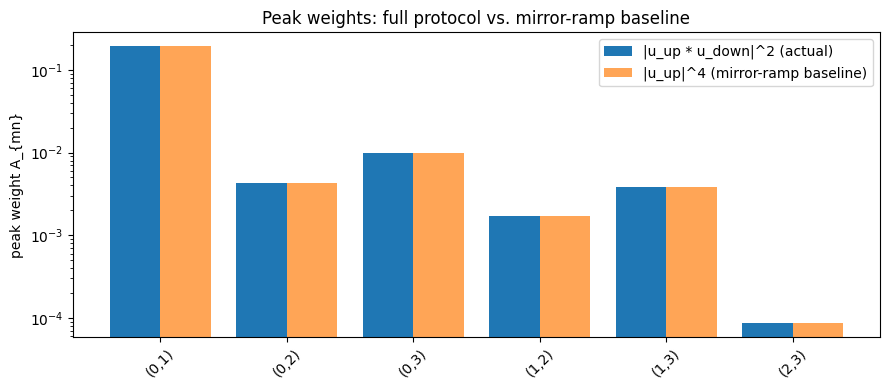

In [37]:
labels = [f'({m},{n})' for m, n, *_ in rows]
x = np.arange(len(rows))
a_full_arr = np.array([r[3] for r in rows])
a_fwd_arr  = np.array([r[4] for r in rows])

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.4
ax.bar(x - w/2, a_full_arr, width=w, label='|u_up * u_down|^2 (actual)')
ax.bar(x + w/2, a_fwd_arr,  width=w, label='|u_up|^4 (mirror-ramp baseline)', alpha=0.7)
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel('peak weight A_{mn}')
ax.set_title('Peak weights: full protocol vs. mirror-ramp baseline')
ax.legend()
plt.tight_layout()
plt.show()

## How to read the result

For each dark peak `(m, n)`, walk the cascade:

1. **`|u_m^↑|` and `|u_n^↑|` populations**: if either is tiny, the state is unreachable from the forward ramp — fix that first (ramp speed, asymmetry, initial state).
2. **`|ρ_{mn}|` at end of ramp 1**: if both populations are healthy but `|ρ_{mn}|` is near zero (the warning list above prints these), the dynamics decoupled m and n into separate symmetry sectors during the forward ramp. *No ramp-down shape will recover this peak.* Break the relevant symmetry in the Hamiltonian or in the forward ramp itself.
3. **`|u_m^↓|` / `|u_n^↓|`**: if these are small while `|u_m^↑|` is healthy, the ramp-down is the closure. Modifying ramp-down can open the channel — at the cost of breaking the mirror-ramp assumption used by the LSZ reconstruction model.